# Tier 14: trajectory optimization on the sized aircraft

Tier 14 flies an **already-sized** Halo aircraft through optimal trajectories. It is separate
from sizing: `solve_halo_sizing()` (900 kg payload, 210 kt, fixed 2 x 1,120 hp turboshafts)
fixes the design, and each trajectory is its own `asb.Opti` whose only variables are states,
controls and the final time.

**What AeroSandbox supplies.**

- Dynamics: `asb.DynamicsPointMass2DSpeedGamma` (wind axes; gravity via `add_gravity_force`).
- Collocation: `constrain_derivatives` / `Opti.constrain_derivative`, trapezoidal, on a
  free-final-time grid `np.linspace(0, duration, n)`.
- Atmosphere: `asb.Atmosphere`.

**What this project adds** (`aircraft_closure.trajectory.tiltrotor`): the tilting rotor thrust,
wing lift and drag from `SimpleAerodynamics`, the rotor -> gearbox -> motor -> bus power chain,
the battery/turbogenerator supply and the energy states (mass, SOC, bus energy).

**Model.**

- Nacelle tilt runs from 90 deg (hover) to 0 deg (airplane). Rotor-axis angle to the flight
  path is phi = alpha + tilt.
- Wind-axis forces are `F_x = n T (1 - f_dl) cos(phi) - D` and
  `F_z = -(n T (1 - f_dl) sin(phi) + L)`.
- Rotor power uses the Tier 12 JVX-calibrated `MomentumProfileRotor`, with the axial
  velocity taken as V cos(phi). **This is an approximation:** edgewise and conversion rotor
  physics are deferred. The airplane-mode coefficients are blended in with cos^2(tilt).
- Download is the hover 7 % (XV-15), faded with sin^2(tilt) and with wake skew.
- Rotor speed is a control at every node. The Tier 12 bounds apply at every node: blade
  loading 0.14, helical tip Mach 0.80, advance ratio 0.60 and design tip speed.
- Power is limited by the motor and gearbox ratings, the generator ratings, the lapsed
  turboshafts (`SimpleTurboshaft.power_available_W`) and the battery discharge rating.
  Recharging in flight is off in these manoeuvres.

**Sources.**

- XV-15 conversion corridor and conversion power: NASA TM X-62407 (XV-15 familiarization
  document), figs. 5.4.1 and 5.4.2. The corridor here is a documented approximation (plan 019).
- Rotor: Acree, NASA/TM-2016-219070 (JVX), as calibrated in plan 016.
- Related practice: Chauhan & Martins, "Tilt-Wing eVTOL Takeoff Trajectory Optimization",
  J. Aircraft 57(1), 2020.

```powershell
uv run jupyter lab notebooks/tier14_trajectory
```

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.performance.flight_point import FlightCondition, acceleration_gravity_m_s2, build_flight_point
from aircraft_closure.trajectory.tiltrotor import TrajectoryGuess, TrajectoryLimits, build_tiltrotor_trajectory
from examples.trajectory_optimization import (altitude_band_transition_m, altitude_transition_m, describe,
                                              halo_trajectory_case, ratio_transition_end_stall,
                                              solve_min_energy_transition, solve_min_time_climb,
                                              solve_prescribed_transition)

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

case = halo_trajectory_case()
model, limits = case.model, TrajectoryLimits()
weight_N = case.mass_kg * acceleration_gravity_m_s2
print(f"Halo reference: {case.mass_kg:,.0f} kg, airplane-mode stall {case.corridor.velocity_stall_m_s:.1f} m/s "
      f"({case.corridor.velocity_stall_m_s / u.knot:.0f} kt), cruise {case.sizing.velocity_cruise_m_s / u.knot:.0f} kt")

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


Halo reference: 6,242 kg, airplane-mode stall 61.0 m/s (119 kt), cruise 156 kt


## 1. Frozen limits recover the quasi-steady flight point

The trajectory model must reduce to the Tier 7-9 quasi-steady flight point (`build_flight_point`)
on the same aircraft.

- **Hover:** tilt 90 deg at zero speed, with the full download.
- **Airplane mode:** thrust along the flight path (tilt = -alpha), which is the flight
  point's own assumption. This reproduces the identity exactly.
- **Collocated trajectory:** nacelles frozen and every node steady. The trajectory picks
  its own trim and rotor speed.
- **Tilt frozen at 0 deg:** thrust then lies along the fuselage at alpha above the path. Its
  lift component unloads the wing, so power is slightly lower. This difference is physical.

In [2]:
def solve_point(condition):
    opti = asb.Opti()
    point = build_flight_point(opti, model.aircraft, model.aerodynamics, condition, case.mass_kg, 0.0)
    opti.minimize(point.fuel_flow_kg_s * 100)
    return point, opti.solve(verbose=False)


hover, hs = solve_point(FlightCondition(mode="hover", altitude_m=0.0, thrust_to_weight=1.0, label="hover"))
f = model.evaluate(0.0, 0.0, 0.0, 90.0, thrust_per_rotor_N=hs.value(hover.thrust_per_rotor_N),
                   speed_rotor_rad_s=hs.value(hover.speed_rotor_rad_s))
ratio_hover = f.power_electric_motors_W / hs.value(hover.power_electric_motors_W)
print(f"hover: bus power {f.power_electric_motors_W / 1e3:,.1f} kW vs flight point "
      f"{hs.value(hover.power_electric_motors_W) / 1e3:,.1f} kW (ratio - 1 = {ratio_hover - 1:.1e})")
check("hover: thrust x (1 - download) carries the weight", abs(f.force_z_wind_N + weight_N) / weight_N < 1e-9)
check("hover: bus power within 1e-5 of the flight point", abs(ratio_hover - 1) < 1e-5)

cruise, cs = solve_point(FlightCondition(mode="airplane", velocity_m_s=80.0, altitude_m=1000.0, label="cruise"))
alpha_deg = cs.value(cruise.alpha_deg)
f = model.evaluate(80.0, 1000.0, alpha_deg, -alpha_deg, thrust_per_rotor_N=cs.value(cruise.thrust_per_rotor_N),
                   speed_rotor_rad_s=cs.value(cruise.speed_rotor_rad_s))
check("airplane identity: forces balance (|F|/W < 1e-9)",
      abs(f.force_x_wind_N) / weight_N < 1e-9 and abs(f.force_z_wind_N + weight_N) / weight_N < 1e-9)
check("airplane identity: bus power equal to the flight point (1e-9)",
      abs(f.power_electric_motors_W / cs.value(cruise.power_electric_motors_W) - 1) < 1e-9)


def frozen(thrust_along_flight_path):
    opti = asb.Opti()
    guess = TrajectoryGuess(duration_s=10.0, velocity_m_s=80.0, altitude_m=1000.0, tilt_deg=0.0,
                            thrust_per_rotor_N=cs.value(cruise.thrust_per_rotor_N))
    t = build_tiltrotor_trajectory(opti, model, mass_initial_kg=case.mass_kg, soc_initial=0.8, count_nodes=5,
                                   duration_bounds_s=(10.0, 10.0), guess=guess,
                                   limits=TrajectoryLimits(tilt_min_deg=-20.0))
    opti.subject_to([t.tilt_deg == (-t.alpha_deg if thrust_along_flight_path else 0.0), t.acceleration_m_s2 == 0,
                     t.rate_gamma_rad_s == 0, t.velocity_m_s[0] == 80.0, t.altitude_m[0] == 1000.0,
                     t.gamma_rad[0] == 0])
    opti.minimize(t.energy_bus_J[-1] / 1e7)
    s = opti.solve(verbose=False)
    return s.value(t.forces.power_electric_motors_W) / cs.value(cruise.power_electric_motors_W)


along, tilt_zero = frozen(True), frozen(False)
print(f"collocated, thrust along path: power ratio {along.min():.5f}-{along.max():.5f} (fuel burn over 10 s)")
print(f"collocated, tilt frozen at 0:  power ratio {tilt_zero.mean():.4f}")
check("collocated steady trajectory recovers flight-point power within 0.05 %", np.all(np.abs(along - 1) < 5e-4))
check("tilt 0: thrust inclination lowers power by less than 2 %", np.all((tilt_zero < 1) & (tilt_zero > 0.98)))

hover: bus power 1,417.0 kW vs flight point 1,417.0 kW (ratio - 1 = 2.1e-06)
PASS  hover: thrust x (1 - download) carries the weight
PASS  hover: bus power within 1e-5 of the flight point
PASS  airplane identity: forces balance (|F|/W < 1e-9)
PASS  airplane identity: bus power equal to the flight point (1e-9)


collocated, thrust along path: power ratio 0.99988-1.00000 (fuel burn over 10 s)
collocated, tilt frozen at 0:  power ratio 0.9807
PASS  collocated steady trajectory recovers flight-point power within 0.05 %
PASS  tilt 0: thrust inclination lowers power by less than 2 %


## 2. Conversion corridor

The corridor is an approximation of the XV-15 corridor (TM X-62407 fig. 5.4.1, 13,000 lb
curves, read to about +/-10 kt).

- **Low-speed boundary** (wing stall and attitude limit): V >= V_stall cos(tilt), using the
  Halo's own airplane-mode stall speed at the aerodynamics model's CLmax.
- **High-speed boundary** (rotor torque and loads): an absolute fit,
  V_90 + (V_0 - V_90)(1 - (tilt/90 deg)^2), with V_90 = 115 kt and V_0 = 180 kt.
- **Wing:** besides the corridor, alpha stays below the model's stall angle at every node.

minimum-energy transition: 24.8 s, bus energy 11.04 kWh, fuel 3.5 kg, SOC 0.950 -> 0.942, peak bus power 1,656 kW
prescribed transition: 60.0 s, bus energy 20.20 kWh, fuel 7.1 kg, SOC 0.950 -> 0.950, peak bus power 1,484 kW
minimum time to climb: 212.2 s, bus energy 94.97 kWh, fuel 27.6 kg, SOC 0.950 -> 0.742, peak bus power 1,631 kW


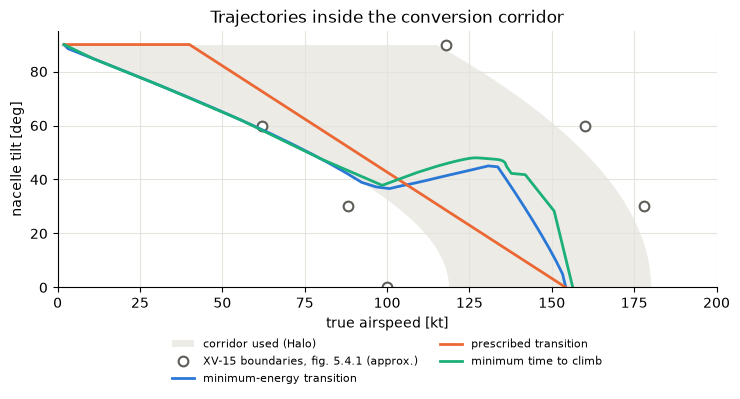

PASS  minimum-energy transition: inside the corridor at every node
PASS  minimum-energy transition: wing below stall angle at every node
PASS  prescribed transition: inside the corridor at every node
PASS  prescribed transition: wing below stall angle at every node
PASS  minimum time to climb: inside the corridor at every node
PASS  minimum time to climb: wing below stall angle at every node


In [3]:
transition = solve_min_energy_transition(case)
prescribed = solve_prescribed_transition(case)
climb = solve_min_time_climb(case)
for r in (transition, prescribed, climb):
    print(describe(r))

tilt_grid = np.linspace(0, 90, 91)
xv15_low = [(0, 100), (30, 88), (60, 62)]          # kt, approximate reading of fig. 5.4.1 (13,000 lb)
xv15_high = [(90, 118), (60, 160), (30, 178)]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.fill_betweenx(tilt_grid, case.corridor.velocity_min_m_s(tilt_grid) / u.knot,
                 case.corridor.velocity_max_m_s(tilt_grid) / u.knot, color=grid_color, alpha=0.7, lw=0,
                 label="corridor used (Halo)")
ax.plot(*zip(*[(v, t) for t, v in xv15_low]), ls="none", marker="o", ms=7, mfc="white", mec=ink_muted, mew=1.5,
        label="XV-15 boundaries, fig. 5.4.1 (approx.)")
ax.plot(*zip(*[(v, t) for t, v in xv15_high]), ls="none", marker="o", ms=7, mfc="white", mec=ink_muted, mew=1.5)
ax.plot(transition.velocity_m_s / u.knot, transition.tilt_deg, color=blue, lw=2, label="minimum-energy transition")
ax.plot(prescribed.velocity_m_s / u.knot, prescribed.tilt_deg, color=orange, lw=2, label="prescribed transition")
ax.plot(climb.velocity_m_s / u.knot, climb.tilt_deg, color=aqua, lw=2, label="minimum time to climb")
ax.set(xlabel="true airspeed [kt]", ylabel="nacelle tilt [deg]", xlim=(0, 200), ylim=(0, 95),
       title="Trajectories inside the conversion corridor")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
plt.tight_layout(); plt.show()

for r in (transition, prescribed, climb):
    check(f"{r.label}: inside the corridor at every node",
          np.all(r.velocity_m_s >= r.velocity_corridor_min_m_s - 1e-6)
          and np.all(r.velocity_m_s <= r.velocity_corridor_max_m_s + 1e-6))
    check(f"{r.label}: wing below stall angle at every node", np.all(r.alpha_deg <= r.alpha_stall_deg + 1e-6))

## 3. Minimum-energy transition

The problem runs from hover at 500 ft to steady wing-borne flight at 1.3 V_stall.

- **Altitude:** held within +/-30 m.
- **Nacelle rate:** at most 8 deg/s.
- **Final time:** free.
- **Objective:** motor (bus) electrical energy.
- **Regularization:** a small term prefers the turbines for the power split and smooth
  controls (below 0.1 % of the objective).

The naive reference is a level, constant-acceleration conversion over 60 s. The nacelles
hold at 90 deg for 15 s and then rotate linearly. A linear schedule from t = 0 leaves the
corridor, and a 40 s version needs more forward thrust than the -10 deg attitude limit allows
at low speed. The reference solves only its trim controls.

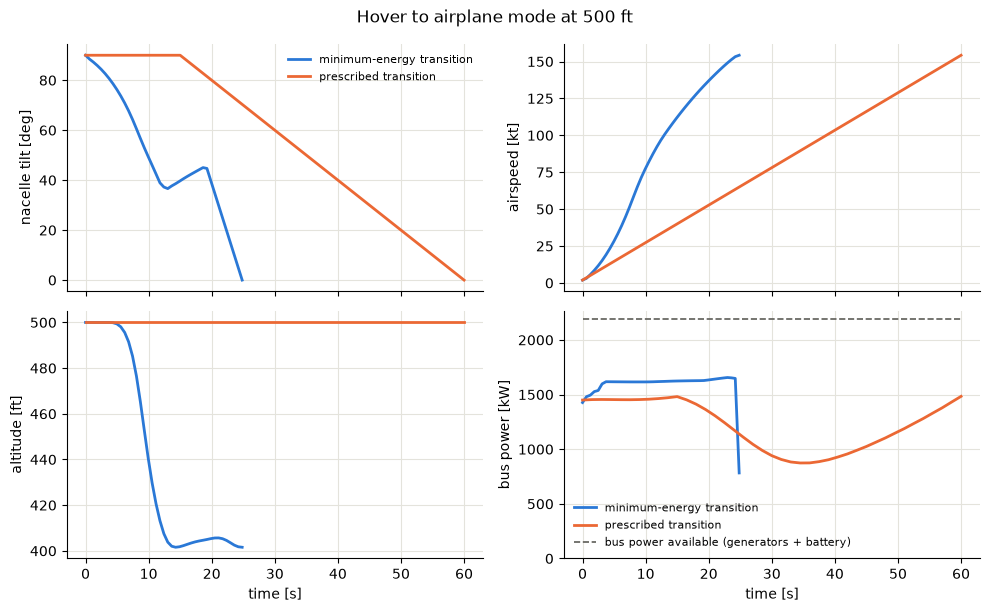

optimal 24.8 s, 11.04 kWh; prescribed 60 s, 20.20 kWh; saving 45%
PASS  transition starts in hover (tilt 90) and ends in airplane mode (tilt 0)
PASS  transition ends steady at 1.3 V_stall
PASS  altitude stays within the +/-30 m band
PASS  nacelle rate within 8 deg/s
PASS  conversion takes at least 90 deg / (8 deg/s)
PASS  optimized transition uses at least 30 % less energy than the prescribed one
PASS  minimum-energy transition: bus power never exceeds power available
PASS  prescribed transition: bus power never exceeds power available


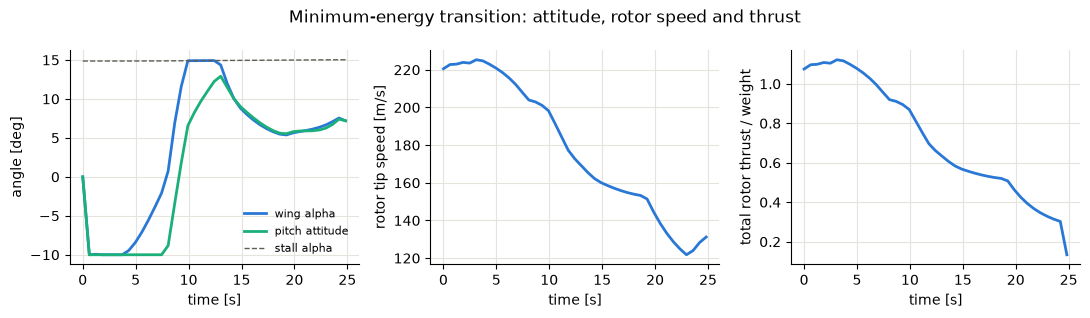

In [4]:
def time_histories(results, title):
    fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), sharex=True)
    for r, color in results:
        axes[0, 0].plot(r.time_s, r.tilt_deg, color=color, lw=2, label=r.label)
        axes[0, 1].plot(r.time_s, r.velocity_m_s / u.knot, color=color, lw=2, label=r.label)
        axes[1, 0].plot(r.time_s, r.altitude_m / u.foot, color=color, lw=2, label=r.label)
        axes[1, 1].plot(r.time_s, r.power_bus_W / 1e3, color=color, lw=2, label=r.label)
    r0 = max((r for r, _ in results), key=lambda r: r.duration_s)
    axes[1, 1].plot(r0.time_s, r0.power_available_bus_W / 1e3, color=ink_muted, lw=1.2, ls="--",
                    label="bus power available (generators + battery)")
    for ax, ylabel in zip(axes.flat, ("nacelle tilt [deg]", "airspeed [kt]", "altitude [ft]", "bus power [kW]")):
        ax.set_ylabel(ylabel)
    axes[1, 0].set_xlabel("time [s]"); axes[1, 1].set_xlabel("time [s]")
    axes[1, 1].set_ylim(0, None)
    axes[0, 0].legend(frameon=False, fontsize=8)
    axes[1, 1].legend(frameon=False, fontsize=8, loc="lower left")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


time_histories([(transition, blue), (prescribed, orange)], "Hover to airplane mode at 500 ft")
saving = 1 - transition.energy_bus_J[-1] / prescribed.energy_bus_J[-1]
print(f"optimal {transition.duration_s:.1f} s, {transition.energy_bus_J[-1] / 3.6e6:.2f} kWh; prescribed "
      f"{prescribed.duration_s:.0f} s, {prescribed.energy_bus_J[-1] / 3.6e6:.2f} kWh; saving {saving:.0%}")
r = transition
check("transition starts in hover (tilt 90) and ends in airplane mode (tilt 0)",
      abs(r.tilt_deg[0] - 90) < 1e-6 and abs(r.tilt_deg[-1]) < 1e-6)
check("transition ends steady at 1.3 V_stall",
      abs(r.velocity_m_s[-1] / (ratio_transition_end_stall * case.corridor.velocity_stall_m_s) - 1) < 1e-6
      and abs(r.acceleration_m_s2[-1]) < 1e-6)
check("altitude stays within the +/-30 m band", np.all(np.abs(r.altitude_m - altitude_transition_m)
                                                         <= altitude_band_transition_m + 1e-4))
check("nacelle rate within 8 deg/s", np.all(np.abs(r.tilt_rate_deg_s) <= limits.tilt_rate_max_deg_s + 1e-6))
check("conversion takes at least 90 deg / (8 deg/s)", r.duration_s >= 90 / limits.tilt_rate_max_deg_s - 1e-6)
check("optimized transition uses at least 30 % less energy than the prescribed one", saving > 0.3)
for res in (transition, prescribed):
    check(f"{res.label}: bus power never exceeds power available",
          np.all(res.power_bus_W <= res.power_available_bus_W * (1 + 1e-6)))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
axes[0].plot(r.time_s, r.alpha_deg, color=blue, lw=2, label="wing alpha")
axes[0].plot(r.time_s, r.pitch_deg, color=aqua, lw=2, label="pitch attitude")
axes[0].plot(r.time_s, r.alpha_stall_deg, color=ink_muted, lw=1, ls="--", label="stall alpha")
axes[0].set(ylabel="angle [deg]"); axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(r.time_s, r.speed_tip_m_s, color=blue, lw=2); axes[1].set(ylabel="rotor tip speed [m/s]")
axes[2].plot(r.time_s, r.thrust_per_rotor_N * model.count("propulsor") / weight_N, color=blue, lw=2)
axes[2].set(ylabel="total rotor thrust / weight")
for ax in axes:
    ax.set_xlabel("time [s]")
fig.suptitle("Minimum-energy transition: attitude, rotor speed and thrust")
plt.tight_layout(); plt.show()

## 4. Minimum time to climb

The problem runs from hover at sea level to steady level flight at 10,000 ft and the sizing
cruise speed, in minimum time.

- **Power limits:** the motors and generators at their ratings, the turboshafts lapsing with
  altitude, and the battery at its discharge rating. SOC stays at or above 0.30.
- **Reference:** the sizing mission flies this climb quasi-steadily at a prescribed 6 m/s.

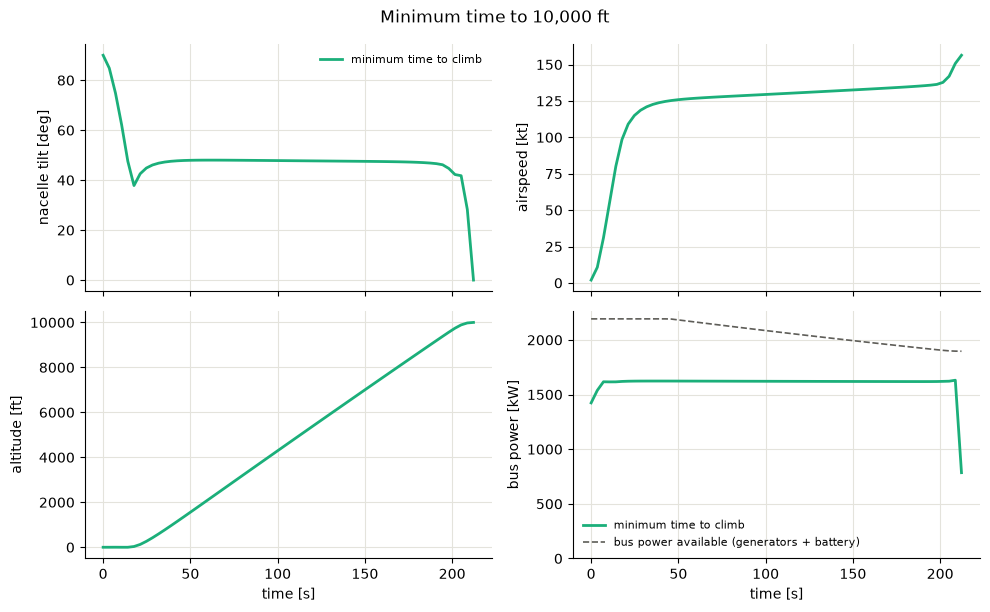

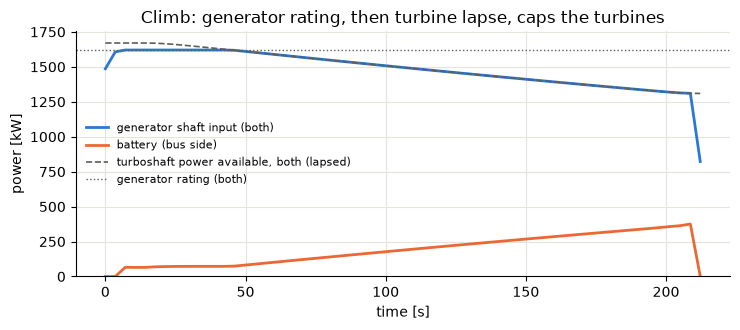

time to climb 212 s (3.5 min), mean climb rate 14.4 m/s (2,827 ft/min), fuel 27.6 kg, SOC 0.95 -> 0.74
climb tilt (middle of the climb) 48 deg, airspeed 130 kt, pitch 20 deg
PASS  reaches 10,000 ft at cruise speed in airplane mode
PASS  bus power never exceeds power available
PASS  generator shaft power never exceeds the lapsed turboshaft
PASS  battery within its discharge rating and SOC floor
PASS  faster than the sizing mission's 6 m/s quasi-steady climb
PASS  energy state equals the integral of bus power


In [5]:
time_histories([(climb, aqua)], "Minimum time to 10,000 ft")
r = climb
fig, ax = plt.subplots(figsize=(7.5, 3.4))
count_generators = model.count("generator")
ax.plot(r.time_s, count_generators * r.power_shaft_generator_W / 1e3, color=blue, lw=2,
        label="generator shaft input (both)")
ax.plot(r.time_s, r.power_battery_W / 1e3, color=orange, lw=2, label="battery (bus side)")
ax.plot(r.time_s, count_generators * r.power_available_turboshaft_W / 1e3, color=ink_muted, lw=1.2, ls="--",
        label="turboshaft power available, both (lapsed)")
ax.axhline(count_generators * model.instance("generator").power_rated_W / 1e3, color=ink_muted, lw=1, ls=":",
           label="generator rating (both)")
ax.set(xlabel="time [s]", ylabel="power [kW]", ylim=(0, None),
       title="Climb: generator rating, then turbine lapse, caps the turbines")
ax.legend(frameon=False, fontsize=8, loc="center left")
plt.tight_layout(); plt.show()

print(f"time to climb {r.duration_s:.0f} s ({r.duration_s / 60:.1f} min), mean climb rate "
      f"{10000 * u.foot / r.duration_s:.1f} m/s ({10000 / (r.duration_s / 60):,.0f} ft/min), fuel "
      f"{r.mass_fuel_burnt_kg:.1f} kg, SOC {r.soc[0]:.2f} -> {r.soc[-1]:.2f}")
print(f"climb tilt (middle of the climb) {np.median(r.tilt_deg):.0f} deg, airspeed "
      f"{np.median(r.velocity_m_s) / u.knot:.0f} kt, pitch {np.median(r.pitch_deg):.0f} deg")
check("reaches 10,000 ft at cruise speed in airplane mode",
      abs(r.altitude_m[-1] - 10000 * u.foot) < 1e-3 and abs(r.tilt_deg[-1]) < 1e-6
      and abs(r.velocity_m_s[-1] - case.sizing.velocity_cruise_m_s) < 1e-6)
check("bus power never exceeds power available", np.all(r.power_bus_W <= r.power_available_bus_W * (1 + 1e-6)))
check("generator shaft power never exceeds the lapsed turboshaft",
      np.all(r.power_shaft_generator_W <= r.power_available_turboshaft_W * (1 + 1e-6)))
check("battery within its discharge rating and SOC floor",
      np.all(r.power_battery_W <= model.instance("battery").max_discharge_power_W * (1 + 1e-6))
      and np.all(r.soc >= limits.soc_min - 1e-6))
check("faster than the sizing mission's 6 m/s quasi-steady climb", r.duration_s < 10000 * u.foot / 6.0)
check("energy state equals the integral of bus power",
      abs(r.energy_bus_J[-1] - np.sum(0.5 * (r.power_bus_W[1:] + r.power_bus_W[:-1]) * np.diff(r.time_s))) / r.energy_bus_J[-1] < 1e-6)

## 5. Reading the result

- **Transition.** The optimum converts in about 22 s. It pitches nose-down to the
  -10 deg attitude limit to accelerate on rotor thrust. It rotates the nacelles as fast as
  the low-speed corridor boundary allows, trades about 30 m of the altitude band for speed,
  and rides the wing near its stall angle in mid-conversion. It finishes at the 8 deg/s
  nacelle rate. Bus power stays at the motor ratings (about 1.7 MW), with the battery
  covering what the two generators can't. Bus energy is roughly half that of the prescribed
  60 s conversion.
- **What limits the transition.** The motor and gearbox ratings, not the engines. Hover
  already draws about 1.5 MW against about 2.2 MW the bus could take from generators plus
  battery.
- **Time to climb.** The optimum climbs at a near-constant 64-68 m/s with the nacelles at
  about 46 deg and the pitch attitude at its 20 deg limit. It converts to airplane mode only
  at the top. **Treat this with caution:** the axial-flow rotor model ignores the edgewise
  component in conversion, so it carries no rise in edgewise profile power and no
  flapping/hub-load penalty apart from the corridor's high-speed boundary. Rotor-borne
  climb therefore looks cheaper than it is. Edgewise rotor physics (Tier 21 conversion work)
  is the deferred remedy, and the conversion-mode climb is the first thing to re-check
  when it lands.
- **Turbine side of the climb.** The generator rating caps the turbines up to about
  7,000 ft (about 140 s). Above that, the lapsed turboshaft power is the cap.
- **Battery.** The battery assists whenever the generators saturate. The 212 s climb uses
  about a third of the pack (SOC 0.95 to about 0.62).

## 6. Summary and unit test suite

In [6]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

26 / 26 notebook checks passed


In [7]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 289 tests in 45.843s

OK
